In [1]:
from multiprocessing import Pool

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import sunpy.visualization.colormaps as cm
from scripts.field_tracing import _worker, arcade, compute_fieldline_transform
from matplotlib.colors import LogNorm
from tqdm import tqdm

In [2]:
data = np.loadtxt("./auxiliary_data/ribbon_bounds.txt", comments="#")

Nx, Ny = 256, 128

param_sets = [
    {
        "Nx": Nx, "Ny": Ny,
        "fpx": tuple(np.round(row[[3,2,1,0]] * Nx).astype(int)),
        "csheight": 64,
        # "fluxratio": np.abs(row[5]) / (row[4] + np.abs(row[5])),
        "fluxratio": 0.99,
        "reczon": 0.15
    }
    for row in data
]

In [3]:
# Uncomment to regenerate magnetic mapping, otherwise reload below

# with Pool(processes=12) as pool:
#     results = list(tqdm(
#         pool.imap(_worker, param_sets),
#         total=len(param_sets)
#     ))

# save_dict = {}
# for i, (left, right) in enumerate(results):
#     save_dict[f"left_{i}"] = left
#     save_dict[f"right_{i}"] = right

# np.savez("./auxiliary_data/magnetic_transforms.npz", **save_dict)

In [4]:
mdata = np.load("./auxiliary_data/magnetic_transforms.npz")
n = len(mdata.files) // 2

results = [(mdata[f"left_{i}"], mdata[f"right_{i}"]) for i in range(n)]

In [5]:
image_struct = np.load("./auxiliary_data/rmap_sji_data.npz")
image = image_struct["rmap_sji_crop"]
image_model_index = image_struct["indices"]

In [6]:
img_ny = 256
dat_ny = image.shape[0]
mod_ny = param_sets[0]["Nx"]
pad = 5

ribbon = 0

img_ribbon = np.zeros((img_ny, image.shape[1]))

for vslice in np.arange(image.shape[1]):

    mapping = results[image_model_index[vslice]][ribbon]

    x0, x1 = param_sets[image_model_index[vslice]]["fpx"][2*ribbon], param_sets[image_model_index[vslice]]["fpx"][2*ribbon+1]

    img_x0, img_x1 = np.floor(x0*dat_ny/mod_ny).astype(int)-pad, np.ceil(x1*dat_ny/mod_ny).astype(int)+pad

    mapping_arr = (mapping[:,0] - mapping[0,0]) / np.max((mapping[:,0] - mapping[0,0]))

    img_chunk = image[img_x0:img_x1, vslice]
    img_coord = np.arange(img_x1 - img_x0) / (img_x1 - img_x0 - 1)

    img_stretch = np.interp(mapping_arr, img_coord, img_chunk)

    original_indices = np.linspace(0, 1, len(img_stretch))
    new_indices = np.linspace(0, 1, img_ny)

    img_ribbon[:,vslice] = np.interp(new_indices, original_indices, img_stretch)

img_ribbon0 = img_ribbon.copy()

In [7]:
img_ny = 256
dat_ny = image.shape[0]
mod_ny = param_sets[0]["Nx"]
pad = 5

ribbon = 1

img_ribbon = np.zeros((img_ny, image.shape[1]))

for vslice in np.arange(image.shape[1]):

    mapping = results[image_model_index[vslice]][ribbon]

    x0, x1 = param_sets[image_model_index[vslice]]["fpx"][2*ribbon], param_sets[image_model_index[vslice]]["fpx"][2*ribbon+1]

    img_x0, img_x1 = np.floor(x0*dat_ny/mod_ny).astype(int)-pad, np.ceil(x1*dat_ny/mod_ny).astype(int)+pad

    mapping_arr = (mapping[:,0] - mapping[0,0]) / np.max((mapping[:,0] - mapping[0,0]))

    img_chunk = image[img_x0:img_x1, vslice]
    img_coord = np.arange(img_x1 - img_x0) / (img_x1 - img_x0 - 1)

    img_stretch = np.interp(mapping_arr, img_coord, img_chunk)

    original_indices = np.linspace(0, 1, len(img_stretch))
    new_indices = np.linspace(0, 1, img_ny)

    img_ribbon[:,vslice] = np.interp(new_indices, original_indices, img_stretch)

img_ribbon1 = img_ribbon.copy()

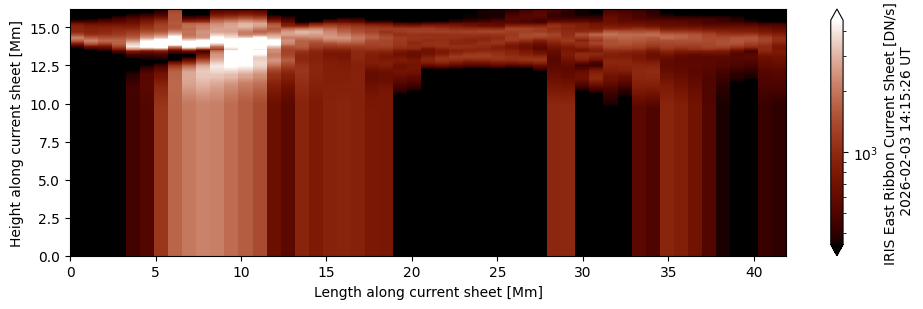

In [10]:
fig, ax = plt.subplots(figsize=[9.85,3.2])
im0 = ax.imshow(img_ribbon0[::-1], aspect="auto", cmap=matplotlib.colormaps['irissji1400'], norm=LogNorm(vmin=350, vmax=4500), extent=[0,41.88,0,16.21], interpolation = "none")
ax.set_xlabel("Length along current sheet [Mm]")
ax.set_ylabel("Height along current sheet [Mm]")

# ax.set_xlim(0,40.2)

plt.colorbar(im0, ax=ax, extend="both", location="right", label="IRIS East Ribbon Current Sheet [DN/s]\n 2026-02-03 14:15:26 UT")

plt.tight_layout()
plt.savefig("./figures/sheetsignal_iris.pdf")

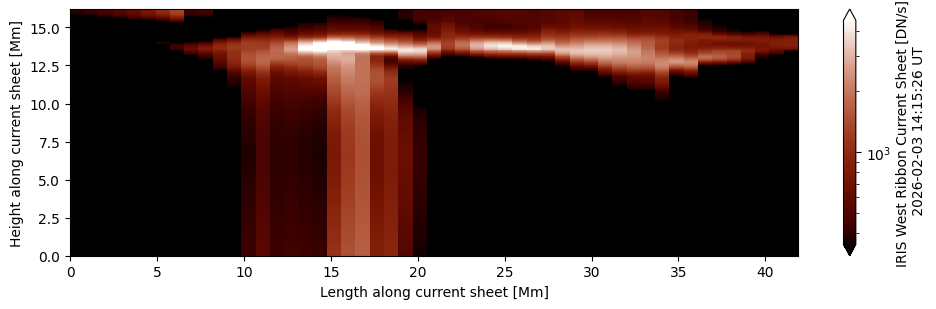

In [9]:
fig, ax = plt.subplots(figsize=[10,3.2])
im1 = ax.imshow(img_ribbon1, aspect="auto", cmap=matplotlib.colormaps['irissji1400'], norm=LogNorm(vmin=350, vmax=4500), extent=[0,41.88,0,16.21], interpolation = "none")
ax.set_xlabel("Length along current sheet [Mm]")
ax.set_ylabel("Height along current sheet [Mm]")

# ax.set_xlim(0,31.09)

plt.colorbar(im1, ax=ax, extend="both", location="right", label="IRIS West Ribbon Current Sheet [DN/s]\n 2026-02-03 14:15:26 UT")

plt.tight_layout()
plt.savefig("./figures/sheetsignal_iris.pdf")